# Recursive submodule refinement & Full workflow:

TODO: Fix single-community case in node_movement_optimization which affects the recursive submodule optimization

In [1]:
# library imports
import igraph as ig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import timeit
import warnings
import random
import sys
sys.path.append("..") # go to parent folder
import src.infomap_funcs as inf

In [2]:
def node_movement_optimization(g, initial_communities=None, teleportation="uniform", returnTerms=False, verbose=False):
    """Phase 1 of the search algorithm. Iteratively moves each node to the
    neighbouring community that minimizes L, until no further improvement.

    Args:
        g: input graph
        initial_communities(list[int], optional): Initial community assignment to start the optimization 
                    from. If None, optimization starts with each node assigned to its own community.   
        teleportation: "uniform" or "nonuniform" (default: uniform).
            For nonuniform, the incremental updates fall back to full recompute,
            making this much slower but still correct.
        returnTerms: whether to also return L, p_mod, exit_data
        verbose: print progress info
    """
    nodes = g.vs.indices
    N_nodes = g.vcount()
    neighborhood = g.neighborhood(mindist=1)

    # if only one node, automatically return it as only community
    # and do not try to optimize
    if N_nodes == 1:
        if verbose:
            print("Graph has only one node, returning it as the only community.")
        if returnTerms:
            L, p, p_mod, exit_data = inf.compute_description_length(
                g, np.array([0]), teleportation=teleportation, returnTerms=True
            )
            return np.array([0]), L, p_mod, exit_data
        else:
            return np.array([0])
        
    # if no initial community assignment is provided,
    # initialize community partition with each node being its own community
    # also do this if there is only 1 community, otherwise there are no neighbouring
    # communities to move to, and the optimization fails
    if initial_communities is None or len(np.unique(initial_communities)) == 1:
        if verbose:
            print("Initialising node movement optimization with each node in its own community.")
        communities = np.arange(N_nodes) # start with each node assigned to its own community
    else: 
        if verbose:
            print("Initialising node movement optimization with the given initial community assignments.")
        communities = initial_communities.copy()
        
    L, p, p_mod, exit_data = inf.compute_description_length(
        g, communities, teleportation=teleportation, returnTerms=True
    )

    if verbose:
        print(f"Starting from description length: {L}")

    optimizable = True
    while optimizable:
        random.shuffle(nodes)
        no_move_ctr = 0

        for n in nodes:
            neighbors = neighborhood[n]
            nb_comms = communities[neighbors]
            src_comm = communities[n]
            comms_to_test = np.unique(nb_comms)
            comms_to_test = comms_to_test[comms_to_test != src_comm]

            L_best, communities_best, p_mod_best, exit_data_best = L, communities.copy(), p_mod.copy(), exit_data.copy()

            for nbc in comms_to_test:
                L_new, communities_new, p_mod_new, exit_data_new = inf.update_node_move_description_length(
                    g, communities, p, p_mod, exit_data, n, nbc,
                    teleportation=teleportation, returnTerms=True
                )
                if L_new is not None and L_new < L_best:
                    L_best, communities_best, p_mod_best, exit_data_best = L_new, communities_new.copy(), p_mod_new.copy(), exit_data_new.copy()

            if communities[n] == communities_best[n]:
                no_move_ctr += 1

            L, communities, p_mod, exit_data = L_best, communities_best.copy(), p_mod_best.copy(), exit_data_best.copy()
            # No relabelling here: empty-community slots stay at zero and are
            # harmless to safe_xlogx. Arrays remain size N throughout the sweep.

        # only stop optimizing if not a single improving move has been made in the sequence
        # otherwise keep optimizing
        optimizable = no_move_ctr < N_nodes

        # End-of-sweep: relabel to compact arrays, then reseed L/p/p_mod/exit_data
        # from scratch so all four are consistent with each other before the next sweep
        # (or before returning). This is the single point where relabelling happens.
        _, communities = np.unique(communities, return_inverse=True)
        L, p, p_mod, exit_data = inf.compute_description_length(
            g, communities, teleportation=teleportation, returnTerms=True
        )

        if verbose:
            print(f"Current best description length: {L}")
            print(f"Number of nodes moved this iteration: {N_nodes - no_move_ctr}")
            if optimizable:
                print("Continuing optimization.")
            else: 
                print("Optimization finished!")

    if verbose:
        print(f"Final number of communities: {len(np.unique(communities))}")
        print(f"Final description length: {L}")

    if returnTerms:
        return communities, L, p_mod, exit_data
    else:
        return communities

In [3]:
def core_search_algorithm(g:ig.Graph, verbose=False):
    """Runs core algorithm of the infomap community partition search algorithm, without any
    refinement steps. Follows the description in "The map equation" (M. Rosvall, D. Axelsson, and C.T. Bergstrom, 2009).
    Alternates between node-movement optimization and network compression until no further improvements can be made.

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: A list of integercommunity labels for each node in the input graph.
    """                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
    N = g.vcount() # number of nodes in graph
    flat_comms = np.arange(N, dtype=int) # we'll use this to track how each node in the og graph
    # maps to the supernodes of the current compressed graph

    g_current = g 
    level = 0 # tracking the compression depth

    # start with a loop that repeats as long as we still have improvements:
    while True:
        n_current = g_current.vcount()
        if verbose:
            print(f"\n--- Level {level} ------------------------------")
            print(f"    Current Graph: {n_current} nodes, {g_current.ecount()} edges")

        L_before = inf.compute_description_length(g_current, np.arange(n_current))
    
        # --- Phase 1: optimization via single-node moves ---
        comms_level, L_after, _, _ = node_movement_optimization(g_current, returnTerms=True, verbose=verbose)
        comms_unique = np.unique(comms_level) # get sorted list of unique communities
        n_communities = len(comms_unique) # number of unique communities

        if verbose:
            print(f"    Phase 1 found {n_communities} communities")

        # if no improvement has been made in node movement optimization, exit loop
        if L_after >= L_before:
            if verbose:
                print("    Node movement did not improve codelength, stopping optimization.")
            break

        # --- Update node mapping ---
        # get for each node in the current level graph the corresponding community
        # indices after optimization (corresponding to supernode indices of the compressed graph
        # that will be created in the next step
        # this should work because comms_evel is already 0-indexed
        flat_comms = comms_level[flat_comms] 
        
        # --- Phase 2: Network compression ---
        g_current, _ = inf.compress_network(g_current, comms_level, verbose=verbose)
        if verbose: 
            print(f"    Compressed network has description length L = {inf.compute_description_length(g_current, range(n_communities))}")
        level += 1
        
    # Normalise: make community labels contiguous and 0-indexed. 
    # (bc rn the labels could have gaps) 
    # works neatly with the inverse labels from np.unique
    _, flat_comms = np.unique(flat_comms, return_inverse=True)

    # assert that we ended up with proper contiguous labelling
    assert set(flat_comms) == set(range(max(flat_comms)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(flat_comms) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."
    
    if verbose:
        L_final = inf.compute_description_length(g, flat_comms.tolist())
        print(f"\nFinal: {len(np.unique(flat_comms))} communities, "
              f"L = {L_final:.6f} bits")

    return flat_comms.tolist()
        

def search_submodules_with_recursion(g, verbose=False):
    """Recursively split graph into submodules based on its current community assignments,
    and run core algorithm on the subgraphs. To be used in the submodule movement optimization step.

    Args:
        g (igraph.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        verbose (bool, optional): Whether to print verbose output for debugging. Defaults to False.

    Returns:
        list[int]: A list of integer community labels for each node in the input graph.
    """
    N = g.vcount()
    if N <= 1:
        if verbose:
            print(f"Base case reached with singleton node (N={N}). Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    comms = np.asarray(core_search_algorithm(g, verbose=verbose), dtype=int)
    unique_comms = np.unique(comms)
    n_comms = len(unique_comms)

    if n_comms == 1:
        if verbose:
            print(f"No improving split for given {N} nodes found. Stopping recursion.")
        return np.zeros(N, dtype=int)
    
    result = np.empty(N, dtype=int)
    next_label = 0

    for c in unique_comms:
        nodes = np.where(comms == c)[0]

        if len(nodes) == 1:
            result[nodes] = next_label
            next_label += 1
            continue

        subgraph = g.induced_subgraph(nodes)
        sub_comms = search_submodules_with_recursion(subgraph, verbose=verbose)

        for s in np.unique(sub_comms):
            result[nodes[sub_comms == s]] = next_label
            next_label += 1

    # sanity check for proper labelling
    assert set(result) == set(range(next_label)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(result) == N, "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    return result

def submodule_movement_optimization(g: ig.Graph, communities: list[int]=None, recursion=False, verbose=False) -> np.ndarray:
    """Refine a community partition via submodule movements:
    1. Take subgraphs corresponding to each module and run node-movement optimization to get 
        submodules
    2. Compress full network such that supernodes correspond to submodules
    3. Run node-movement optimization again, but startunf from the parent-module assignments

    Args:
        g (ig.Graph): Input graph. Supports directed/undirected and weighted/unweighted.
        communities (list[int] | np.ndarray): Community label for each node. (Labels need
            not be 0-indexed or contiguous).
        recursion (bool, optional): Whether to apply the submodule movement optimization recursively to the subgraphs. Defaults to False.
        verbose (bool, optional): Print progress information. Defaults to False.

    Returns:
        np.ndarray: Refined community assignment for every node of g.
    """
    
    if communities is None:
        if verbose:
            print("No initial partition provided, running core search algorithm first.")
        communities = core_search_algorithm(g, verbose=verbose)

    communities = np.array(communities, dtype=int)
    L_before = inf.compute_description_length(g, communities)


    # Normalise community labels to contiguous 0-indexed integers.
    unique_comms = np.unique(communities)          # sorted unique labels
    n_mods       = len(unique_comms)
    comm_idx     = np.searchsorted(unique_comms, communities)   # 0-indexed community per node

    # node indices belonging to each module (list of 1-D arrays)
    comm_nodes = [np.where(comm_idx == i)[0] for i in range(n_mods)]

    if verbose:
        print(f"Submodule refinement: Starting with {n_mods} modules, {g.vcount()} nodes and {g.ecount()} edges total.")
        print(f"Initial description length: {L_before:.2f} bits.")

        #for i, (comm, nodes) in enumerate(zip(unique_comms, comm_nodes)):
        #    print(f"  Module {comm} (idx {i}): {len(nodes)} nodes.")

    # Take each module and extract the corresponding subgraph, 
    # run the main node-movement optimisation and map the resulting local labels
    # to globally unique integers, simultaneously recording each submodule's
    # parent module index.
    global_submodule = np.empty(g.vcount(), dtype=int)  # global submodule label per node
    submodule_to_parent: list[int] = []  # parent module idx per submodule

    offset = 0 # offset to help with contiguous submodule labelling 
    for mod_idx, (nodes, subgraph) in enumerate(
        zip(comm_nodes, [g.induced_subgraph(nodes) for nodes in comm_nodes])): # get subgraphs corresponding to each community
        
        if verbose:
            print(f"\n--- Parent module {mod_idx} ---")
            print(f"Nodes: {len(nodes)}")
            print(f"Subgraph: {subgraph.vcount()} nodes, {subgraph.ecount()} edges")
        if recursion:
            # start recursive process
            local_comms = search_submodules_with_recursion(subgraph, verbose=verbose)
        else:
            # no recursion,just perform node movement optimization step
            local_comms = np.array(node_movement_optimization(subgraph, verbose=verbose), dtype=int)

        if verbose:
            print(f"local_comms: {local_comms}")
            print(f"unique local submodules: {np.unique(local_comms)}")
            print(f"n_submodules: {len(np.unique(local_comms))}")

        # Normalise local labels to contiguous 0-indexed integers,
        # then shift by offset to make them globally unique.
        local_unique  = np.unique(local_comms) # unique local submodule labels
        local_idx     = np.searchsorted(local_unique, local_comms)  # 0-indexed within module
        n_submodules  = len(local_unique) # number of submodules for the given subgraph

        global_submodule[nodes] = local_idx + offset # global submodule labels

        if verbose:
            print(f"offset: {offset}")
            print(f"local_idx: {local_idx}")
            print(f"global labels assigned: {global_submodule[nodes]}")

        # Each local submodule belongs to the current parent module.
        submodule_to_parent.extend([mod_idx] * n_submodules) # update parent map
        offset += n_submodules # update offset

    submodule_to_parent = np.array(submodule_to_parent, dtype=int)
    n_total_submodules  = offset # total number of submodules

    if verbose:
        print(f"Created {n_total_submodules} submodules across {n_mods} modules.")

    # Network compression: each supernode corresponds to one submodule.
    # also returns unique submodule labels to allow reconstruction of node assignments
    g_compressed, unique_submodule_labels = inf.compress_network(g, global_submodule, verbose=verbose)
    
    # unique_submodule_labels[i] is the global submodule label of compressed node i,
    # so indexing submodule_to_parent with it gives the parent module index for each compressed node.
    initial_compressed_comms = submodule_to_parent[unique_submodule_labels]

    if verbose:
        print(f"  Compressed nodes: {g_compressed.vcount()}, "
              f"unique initial communities: {len(np.unique(initial_compressed_comms))}")

    # Performing node-movement optimization on compressed network, with an initial
    # community partition corresponding to the result of the core search algorithm
    # so each compressed node (submodule) is initially assigned to its parent module.
    final_compressed_comms = np.array(
        node_movement_optimization(g_compressed,
                                       initial_communities=initial_compressed_comms,
                                       verbose=verbose,
                                       ),
        dtype=int,
    )

    if verbose:
        print("\nAfter compressed optimisation:")
        print(f"final_compressed_comms: {final_compressed_comms}")

    # map the refined partition back to og nodes
    submodule_to_compressed = {label: idx for idx, label in enumerate(unique_submodule_labels)}
    compressed_node_idx = np.array([submodule_to_compressed[s] for s in global_submodule])
    final_communities   = final_compressed_comms[compressed_node_idx]

    if verbose:
        n_final = len(np.unique(final_communities))
        print(f"Submodule refinement complete: {n_mods} -> {n_final} communities.")
        print(f"Description length: {inf.compute_description_length(g, communities)} -> {inf.compute_description_length(g, final_communities)}")

        # assert that we ended up with proper contiguous labelling
    assert set(final_communities) == set(range(max(final_communities)+1)), "Error: non-contiguous or non-0-indexed labels in recursive submodule search result."
    assert len(final_communities) == g.vcount(), "Error: result length doesn't match number of nodes in graph in recursive submodule search result."

    # one last check to be super sure to only accept improvments
    L_after  = inf.compute_description_length(g, final_communities)
    if L_after < L_before:
        return final_communities
    else:
        return communities
    

    
def search_community_partition(g:ig.Graph, max_iter=100, verbose=False):
    # the full workflow including core + refinements

    N = g.vcount() # number of nodes in graph
    if verbose:
        print(f"\n---  Starting community partition search------------------------------")
        print(f"    Current Graph: {N} nodes, {g.ecount()} edges")
        print(f"    Starting from description length L = {inf.compute_description_length(g, range(N))} bits (with trivial parititon)")

    comms_initial = core_search_algorithm(g, verbose=verbose) # runs core optimization

    if verbose:
        L_initial = inf.compute_description_length(g, comms_initial)
        print(f"Initial partition found by core search algorithm has description length L = {L_initial:.6f} bits")
        print(f"--- Starting refinement process...\n")

    # start with a loop that repeats as long as we still have improvements:
    comms_level = comms_initial
    for i in range(max_iter):
        if verbose:
            print(f"\n--- Refinement: Starting Iteration {i+1}")
        L_before = inf.compute_description_length(g, comms_level)
        # submodule refinement
        comms_level = submodule_movement_optimization(g, comms_level, recursion=True,verbose=verbose)
        # single-node refinements
        comms_level = node_movement_optimization(g, comms_level, verbose=verbose)
        L_after = inf.compute_description_length(g, comms_level)
        if verbose:
            print(f"--- Refinement: Finished Iteration {i+1}")
            print(f"        L_before={L_before:.6f}, L_after={L_after:.6f}")
            print(f"        Current number of communities: {len(np.unique(comms_level))}")
        if (L_after >= L_before):
            break
        
    if i >= max_iter-1:
        warnings.warn(f"Reached maximum number of iterations ({max_iter}), stopping refinement process.")


    comms_unique = np.unique(comms_level) # get sorted list of unique communities
    n_communities = len(comms_unique) # number of unique communities

    if verbose:
        L_final = inf.compute_description_length(g, comms_level.tolist())
        print(f"\nFinal: {n_communities} communities, "
              f"L = {L_final:.6f} bits")

    return comms_level.tolist()

In [4]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def compare_partitions(comms1, comms2):
    if len(comms1) != len(comms2):
        raise ValueError(f"Partition shape mismatch: comms1 and comms2 have different lengths ({len(comms1)} and {len(comms2)}).")

    n_comms1 = len(set(comms1))
    n_comms2 = len(set(comms2))

    print(f"Comparing partitions:\nPartition 1: {n_comms1} communities\nPartition 2: {n_comms2} communities")

    nmi = normalized_mutual_info_score(comms1, comms2)
    ari = adjusted_rand_score(comms1, comms2)

    print(f"Normalized Mututal Information: {nmi:.4f}") # that one we know, between 0 and 1, if 1 -> identical partition
    # Rand score: label agreements/(label agreements + label disagreements), again, between 0 and 1, 1 -> identical partition
    # Adjusted rand score: "Adjusted for change": (RI - Expected_RI) / (max(RI) - Expected_RI)
    print(f"Adjusted Rand Index: {ari:.4f}")  # between -0.5 and 1.0, 0 -> random, 1.0 -> identical

    #return nmi, jaccard, ari

Generating the test networks:

In [5]:
g_test = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
g_test_directed = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=True, weighted=True)

Ok, let's check if it's generally possible to achieve improvements via the submodule movements:

In [6]:
random_partition = np.random.randint(0, g_test.vcount()-1, g_test.vcount())
print("random partition labels:")
print(np.unique(random_partition))

refined = submodule_movement_optimization(
    g_test,
    communities=random_partition,
    recursion=True,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = inf.compute_description_length(g_test, random_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with random partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

random partition labels:
[  1   2   4   6   9  12  13  14  15  16  19  21  22  23  27  30  32  33
  35  37  40  42  43  52  53  54  58  64  66  67  69  70  71  72  73  74
  76  78  79  80  81  82  83  86  90  93  95  97  98  99 101 102 103 104
 106 107 110 112 113 115 116 119 120 121 122 124 125 127 128 129 131 132
 133 136 137 140 141 142 143 147 149 150 151 152 153 154 156 157 158 159
 160 162 164 168 169 170 172 174 175 176 177 178 179 180 181 182 183 184
 185 186 188 191 192 193 194 195 197 198]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Description length with random partition: 9.495343 bits
Description length with refined partition: 6.449336 bits


In [7]:
trivial_partition = np.arange(g_test.vcount())
print("Trivial partition labels:")
print(np.unique(trivial_partition))

refined = submodule_movement_optimization(
    g_test,
    communities=trivial_partition,
    recursion=True,
    verbose=False
)

print("refined partition labels:")
print(np.unique(refined))

Before = inf.compute_description_length(g_test, trivial_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with coarse partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

Trivial partition labels:
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]
refined partition labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]
Description len

This is the one case that used to fail without the adjustment of the node movement optimization.:

In [8]:
coarse_partition = np.zeros(g_test.vcount(), dtype=int)
print("coarse partition labels:")
print(np.unique(coarse_partition))
refined = submodule_movement_optimization(
    g_test,
    communities=coarse_partition,
    recursion=True,
    verbose=False
)
print("refined partition labels:")
print(np.unique(refined))
Before = inf.compute_description_length(g_test, coarse_partition)
After  = inf.compute_description_length(g_test, refined)
print(f"Description length with coarse partition: {Before:.6f} bits")
print(f"Description length with refined partition: {After:.6f} bits")

coarse partition labels:
[0]
refined partition labels:
[0 1 2 3 4 5 6 7]
Description length with coarse partition: 7.563303 bits
Description length with refined partition: 6.137857 bits


Test on undirected:

In [9]:
g_test = inf.generate_sbm(n=200, c=6, p_in=0.25, p_out=0.01, directed=False, weighted=True)
initial_partition = core_search_algorithm(g_test, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test, initial_partition, recursion=True, verbose=True)

print("Before:", inf.compute_description_length(g_test, initial_partition))
print("After: ", inf.compute_description_length(g_test, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Submodule refinement: Starting with 6 modules, 200 nodes and 985 edges total.
Initial description length: 6.06 bits.

--- Parent module 0 ---
Nodes: 35
Subgraph: 35 nodes, 144 edges

--- Level 0 ------------------------------
    Current Graph: 35 nodes, 144 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 7.04649758173383
Current best description length: 5.619234134405434
Number of nodes moved this iteration: 24
Continuing optimization.
Current best description length: 5.532357327469828
Number of nodes moved this iteration: 3
Continuing optimization.
Current best description length: 5.532357327469828
Number of nodes moved this iteration: 0
Optimization finished!
Final number of communities: 12
Final description length: 5.532357327469828
    Phase 1 found 12 communities
Input graph has 12 unique communities, 35 nodes and 144 edges.
Creating compressed graph wi

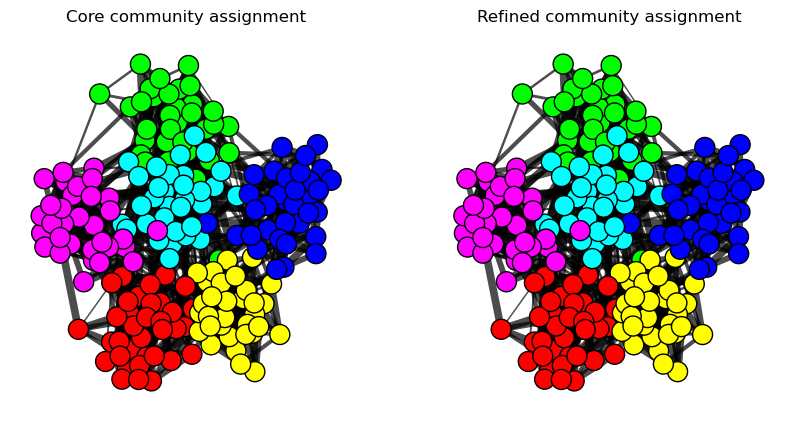

In [10]:
layout = g_test.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=initial_partition, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=refined_partition, skipLayout=True), target=ax[1])
ax[0].set_title("Core community assignment")
ax[1].set_title("Refined community assignment")
plt.show()

Testing the full optimization workflow:

In [11]:
comms = search_community_partition(g_test, verbose=True)


---  Starting community partition search------------------------------
    Current Graph: 200 nodes, 985 edges
    Starting from description length L = 9.569469241523924 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 200 nodes, 985 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 9.569469241523924
Current best description length: 7.821848804268848
Number of nodes moved this iteration: 142
Continuing optimization.
Current best description length: 7.333437319742097
Number of nodes moved this iteration: 50
Continuing optimization.
Current best description length: 7.1102210966627375
Number of nodes moved this iteration: 21
Continuing optimization.
Current best description length: 7.0137745283676
Number of nodes moved this iteration: 17
Continuing optimization.
Current best description length: 6.881967526759486
Number of nodes moved this iteration: 13
Continuing optimization.
C

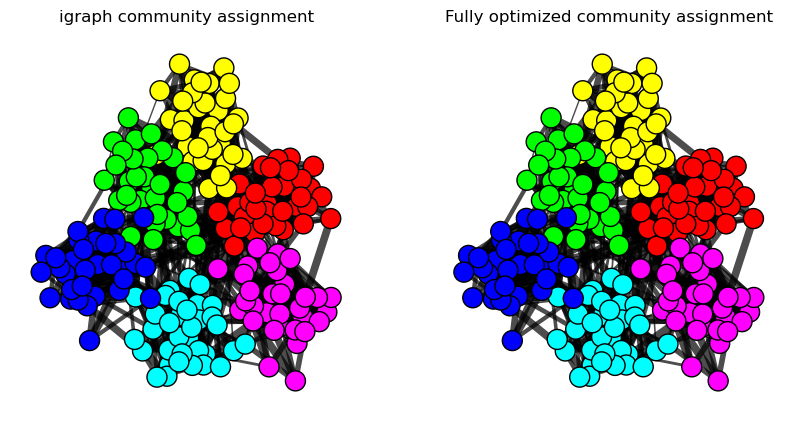

In [12]:
layout = g_test.layout('fr')
comms_ig = g_test.community_infomap(edge_weights=g_test.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test, layout=layout, **inf.visual_community_colors(g_test, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [13]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", inf.compute_description_length(g_test, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", inf.compute_description_length(g_test, comms_ig.membership))

Comparing partitions:
Partition 1: 6 communities
Partition 2: 6 communities
Normalized Mututal Information: 1.0000
Adjusted Rand Index: 1.0000
custom description length:  6.035121386610816
igraph description length:  6.03512138661082
igraph description length w custom computation:  6.035121386610816


Test on directed:

In [14]:
initial_partition = core_search_algorithm(g_test_directed, verbose=False)
print("\nFinished core algorithm!! \nStarting refinement process...\n")

refined_partition = submodule_movement_optimization(g_test_directed, initial_partition, recursion=True, verbose=True)

print("Before:", inf.compute_description_length(g_test_directed, initial_partition))
print("After: ", inf.compute_description_length(g_test_directed, refined_partition))


Finished core algorithm!! 
Starting refinement process...

Submodule refinement: Starting with 6 modules, 200 nodes and 1954 edges total.
Initial description length: 6.57 bits.

--- Parent module 0 ---
Nodes: 34
Subgraph: 34 nodes, 301 edges

--- Level 0 ------------------------------
    Current Graph: 34 nodes, 301 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 6.978881661769851
Current best description length: 6.00518198071042
Number of nodes moved this iteration: 27
Continuing optimization.
Current best description length: 5.733625887894691
Number of nodes moved this iteration: 10
Continuing optimization.
Current best description length: 5.660124516794819
Number of nodes moved this iteration: 5
Continuing optimization.
Current best description length: 5.577860879752342
Number of nodes moved this iteration: 2
Continuing optimization.
Current best description length: 5.577860879752342
Number of nodes moved this it

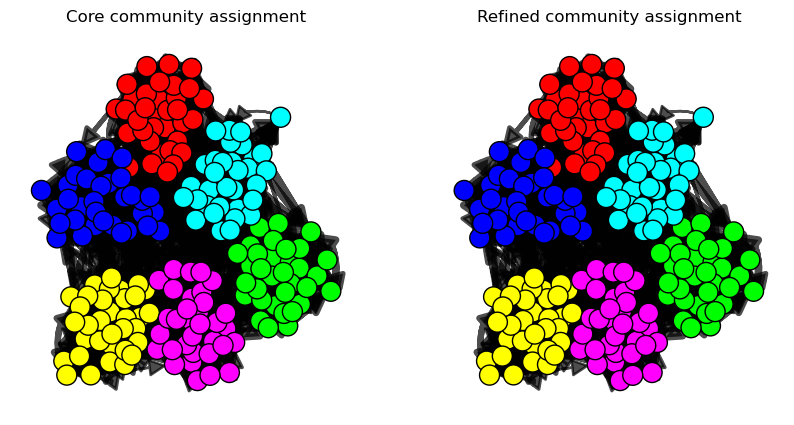

In [15]:
layout = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=initial_partition, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=refined_partition, skipLayout=True), target=ax[1])
ax[0].set_title("Core community assignment")
ax[1].set_title("Refined community assignment")
plt.show()

Testing the full optimization workflow:

In [16]:
comms = search_community_partition(g_test_directed, verbose=True)


---  Starting community partition search------------------------------
    Current Graph: 200 nodes, 1954 edges
    Starting from description length L = 9.565067775656066 bits (with trivial parititon)

--- Level 0 ------------------------------
    Current Graph: 200 nodes, 1954 edges
Initialising node movement optimization with each node in its own community.
Starting from description length: 9.565067775656066
Current best description length: 8.231039216940312
Number of nodes moved this iteration: 161
Continuing optimization.
Current best description length: 7.709027119874069
Number of nodes moved this iteration: 76
Continuing optimization.
Current best description length: 7.228181081014885
Number of nodes moved this iteration: 48
Continuing optimization.
Current best description length: 7.031903253800969
Number of nodes moved this iteration: 25
Continuing optimization.
Current best description length: 6.81406285247731
Number of nodes moved this iteration: 16
Continuing optimization.

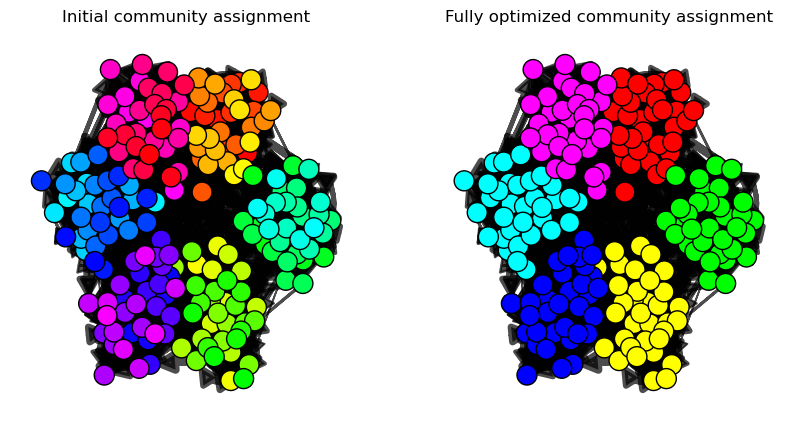

In [17]:
layout = g_test_directed.layout('fr')
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=range(g_test_directed.vcount()), skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("Initial community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

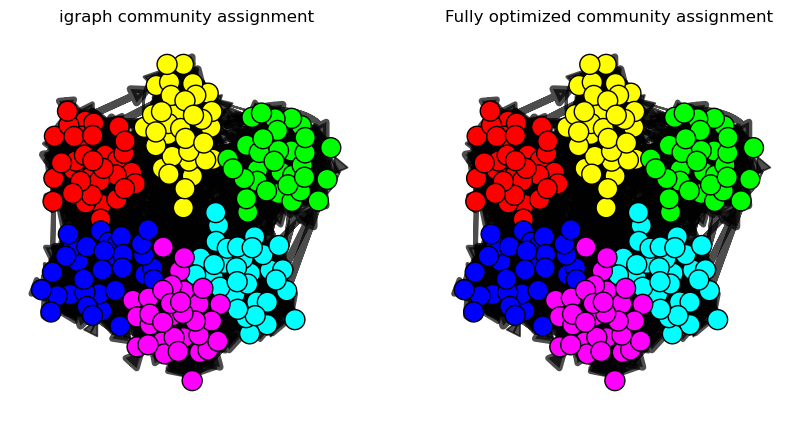

In [18]:
layout = g_test_directed.layout('fr')
comms_ig = g_test_directed.community_infomap(edge_weights=g_test_directed.es['weight'], vertex_weights=None, trials=10)
fig, ax = plt.subplots(ncols=2, figsize = (10, 5))
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms_ig.membership, skipLayout=True), target=ax[0])
ig.plot(g_test_directed, layout=layout, **inf.visual_community_colors(g_test_directed, communities=comms, skipLayout=True), target=ax[1])
ax[0].set_title("igraph community assignment")
ax[1].set_title("Fully optimized community assignment")
plt.show()

In [19]:
compare_partitions(comms, comms_ig.membership)
print("custom description length: ", inf.compute_description_length(g_test_directed, comms))
print("igraph description length: ", comms_ig.codelength)
print("igraph description length w custom computation: ", inf.compute_description_length(g_test_directed, comms_ig.membership))


Comparing partitions:
Partition 1: 6 communities
Partition 2: 6 communities
Normalized Mututal Information: 1.0000
Adjusted Rand Index: 1.0000
custom description length:  6.566585628602532
igraph description length:  6.140773795020754
igraph description length w custom computation:  6.566585628602532
